Re-think of [jax_wcs_experimentation_part2.ipynb](jax_wcs_experimentation_part2.ipynb)

In [1]:
import time
from pathlib import Path
from matplotlib import pyplot as plt

import numpy as np

from jwst import datamodels

from astropy import units as u
from astropy.coordinates import SkyCoord, SpectralCoord

import jax
from jax import numpy as jnp
import equinox as eqx
import optax

from tqdm.auto import tqdm

jax.devices()

[CudaDevice(id=0)]

# Data

In [ ]:
n6791fits = list(Path('../ngc6791_cals').glob('*.fits'))
n6791dms = [datamodels.open(fn) for fn in n6791fits]

dm0 = n6791dms[0]
s = dm0.slits[42]
swcs = s.meta.wcs

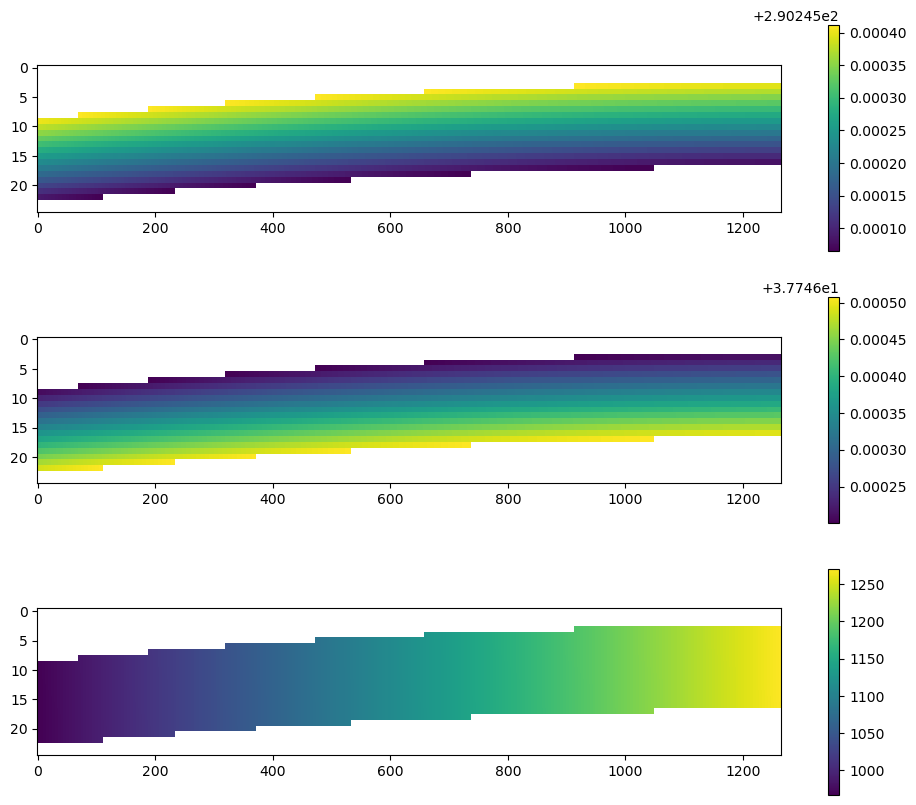

In [ ]:
yg, xg = np.indices(s.data.shape)

sky,spec = swcs.pixel_to_world(xg, yg)
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10))

sc = ax1.imshow(sky.ra.deg, aspect=10, interpolation='nearest')
plt.colorbar(sc, ax=ax1)
sc = ax2.imshow(sky.dec.deg, aspect=10, interpolation='nearest')
plt.colorbar(sc, ax=ax2)
sc = ax3.imshow(spec.to_value(u.nm), aspect=10, interpolation='nearest')
plt.colorbar(sc, ax=ax3)

In [ ]:
class SlitScaling:
    def __init__(self, slitshape, wcs, extra_in_offset=1): # not slitshape will be y,x not x,y despite wcs being the normal way
        self.slitshape = slitshape
        self.wcs = wcs
        self.extra_in_offset = extra_in_offset

        self._compute_inbounds()
        self._compute_outbounds()

    def _compute_inbounds(self):
        self.inscale = jnp.array((self.slitshape[1], self.slitshape[0]))
        self.inoffset = -self.extra_in_offset * jnp.ones(2)

    def _compute_outbounds(self):
        world = self.world_grid()
        worldflat = world.reshape(3, -1)
        self.outoffset = mi = jnp.nanmin(worldflat, axis=1)
        mx = jnp.nanmax(worldflat, axis=1)
        self.outscale = mx - mi

    def xy_grid(self):
        yg, xg = jnp.mgrid[:self.slitshape[0], :self.slitshape[1]]
        return jnp.stack([xg, yg[::-1]], axis=0)
    
    def xy_grid_rescaled(self):
        return self.rescale_input(self.xy_grid())

    def world_grid(self):
        return jnp.array(self.wcs.pixel_to_world_values(*self.xy_grid()))
    
    def world_grid_rescaled(self):
        return self.rescale_output(self.world_grid())
    
    def rescale_input(self, xy):
        return ((xy.T - self.inoffset) / self.inscale).T * 2 - 1
    
    def rescale_output(self, out):
        return ((out.T - self.outoffset) / self.outscale).T * 2 - 1

    def restore_output(self, outscaled):
        return ((outscaled+1/2).T * self.outscale + self.outoffset).T
    
ss = SlitScaling(s.data.shape, swcs)

In [ ]:
xygrf = ss.xy_grid_rescaled().reshape(2, -1)

vander = np.polynomial.polynomial.polyvander2d(xygrf[0], xygrf[1], [3,3])
vander.shape

(31650, 16)

In [ ]:
worldf = ss.world_grid().reshape(3, -1)
msk = np.isfinite(worldf).all(axis=0)
worldf = worldf[:, msk]
vanderf = vander[msk]

res = np.linalg.lstsq(vanderf, worldf.T, rcond=None)
res

(array([[ 2.9024524e+02,  3.7746357e+01,  1.1191880e+00],
        [-3.0047333e-04,  2.6823519e-04, -2.2385355e-04],
        [-3.2157891e-06, -4.4278945e-08,  7.2148782e-07],
        [-1.1287429e-05, -1.6320941e-07,  5.6863939e-07],
        [-7.6400269e-05,  6.7348104e-05,  1.5193966e-01],
        [-2.4547105e-06,  9.4051828e-08, -4.0791042e-06],
        [ 2.2244685e-06,  5.9681305e-08,  6.1067237e-07],
        [ 2.8118654e-06,  1.4081186e-07,  4.9904379e-06],
        [ 3.2258518e-05, -2.9359035e-05, -3.5614372e-04],
        [-5.5210671e-06, -1.7311437e-07,  1.1012013e-06],
        [ 1.4605940e-05,  3.2598254e-07, -4.3964296e-06],
        [ 5.7449164e-05,  1.0254386e-06, -8.9961316e-07],
        [-3.1272299e-07,  3.4717408e-07, -2.7841375e-05],
        [-1.7087050e-06,  1.0948454e-07, -8.0536313e-07],
        [ 1.7725570e-05,  3.8082123e-07,  1.3241173e-07],
        [ 3.2192700e-05,  3.5135946e-07, -1.0661669e-05]], dtype=float32),
 array([1.4415689e-06, 2.2058035e-08, 1.3802287e-09], d

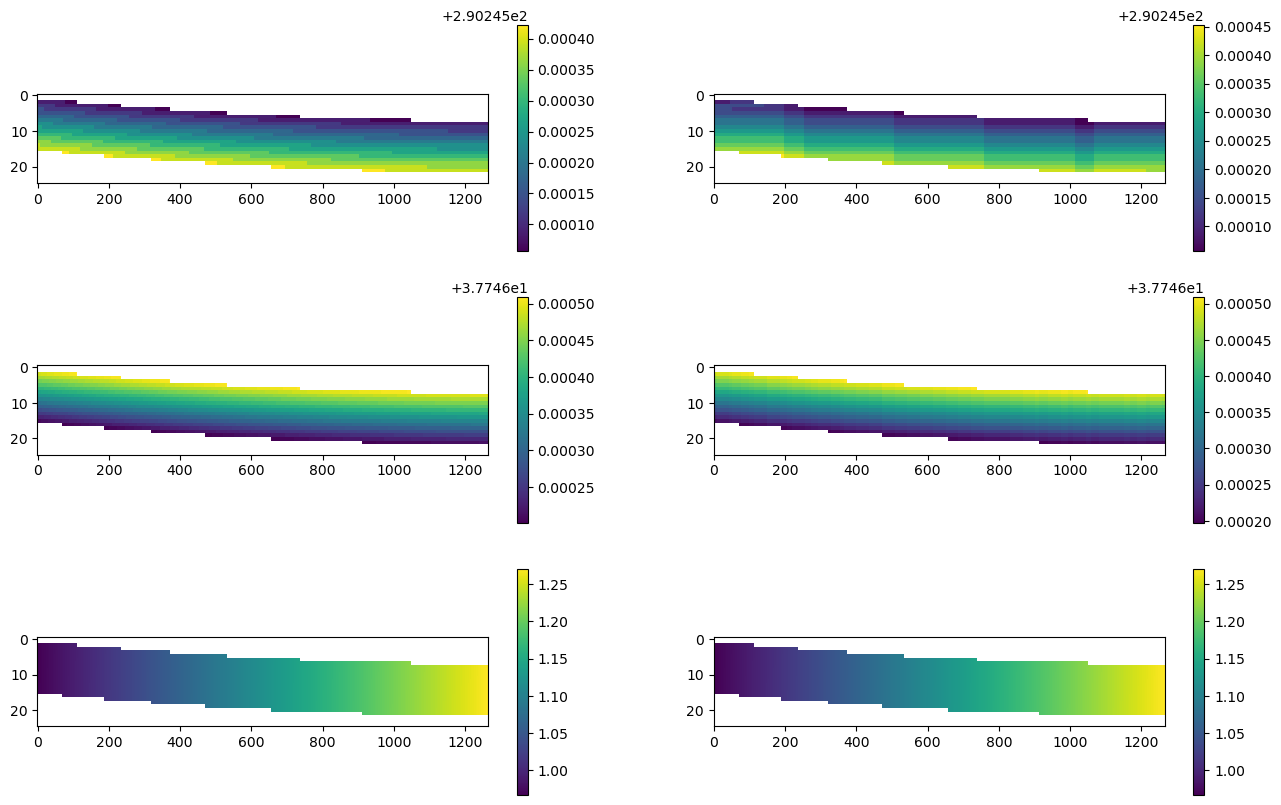

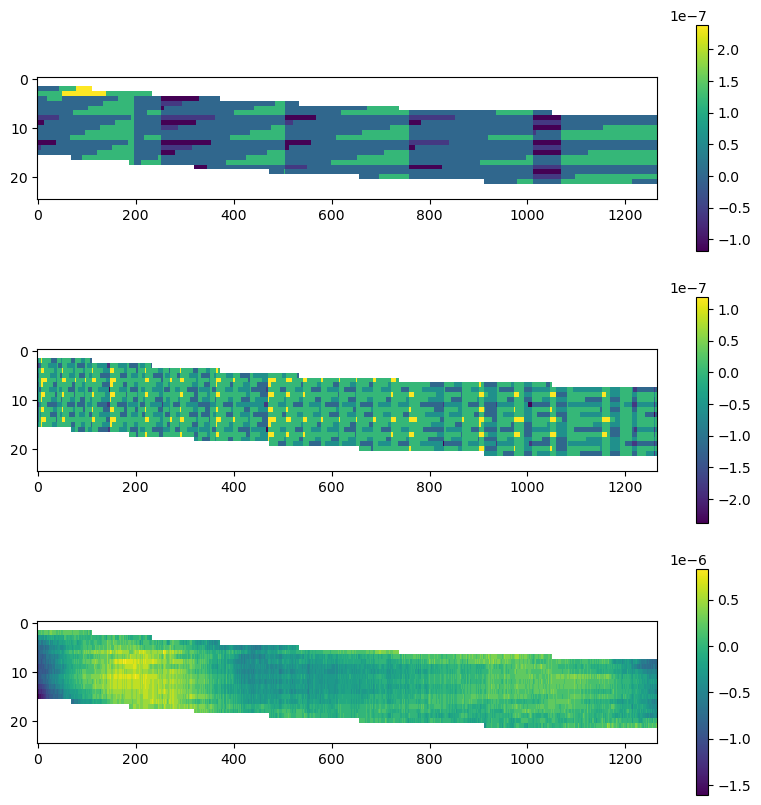

In [ ]:
coeffs = res[0]
vals = (vander @ coeffs).T.reshape(3, *ss.slitshape)

worldg = ss.world_grid()

fig, axs = plt.subplots(3, 2, figsize=(16, 10))
for i, (ax1, ax2) in enumerate(axs):
    sc = ax1.imshow(worldg[i], aspect=10, interpolation='nearest')
    plt.colorbar(sc, ax=ax1)
    sc = ax2.imshow(vals[i] + (worldg[i] - worldg[i]), aspect=10, interpolation='nearest')
    plt.colorbar(sc, ax=ax2)

fig, axs = plt.subplots(3, 1, figsize=(10, 10))
for i, ax in enumerate(axs):
    sc = ax.imshow(vals[i]/worldg[i] - 1, aspect=10, interpolation='nearest')
    plt.colorbar(sc, ax=ax)

Does jax give the same answer?

(Array([[ 2.9024518e+02,  3.7746353e+01,  1.1191877e+00],
        [-2.6580133e-04,  2.5970256e-04, -2.2449817e-04],
        [ 7.2792172e-05,  1.6476959e-05,  1.4188699e-06],
        [ 7.1823597e-05,  3.4820288e-05,  3.4566037e-06],
        [-6.3173473e-05,  5.9336424e-05,  1.5193984e-01],
        [ 5.2998774e-05,  2.6843394e-05, -4.3620530e-06],
        [-1.8125772e-04,  4.3898821e-05,  1.0998920e-06],
        [-1.5437603e-04, -3.5834499e-05,  6.0193706e-06],
        [-4.2468309e-07, -4.5826659e-05, -3.5654075e-04],
        [-3.0494854e-04, -3.8640574e-06,  8.9168316e-07],
        [ 3.1578541e-04,  7.0542097e-05, -2.5304034e-06],
        [-3.6716461e-05,  5.4135919e-05, -4.3539330e-07],
        [-6.1690807e-05,  2.9830262e-06, -2.7942820e-05],
        [ 2.2144616e-04, -2.5387853e-05, -2.4377368e-07],
        [-3.2335520e-04, -3.8057566e-05, -9.4156712e-07],
        [-6.5326691e-05,  1.0727346e-04, -9.3467534e-06]], dtype=float32),
 Array([1.0672864e-04, 2.0238515e-06, 3.7847090e-09], d

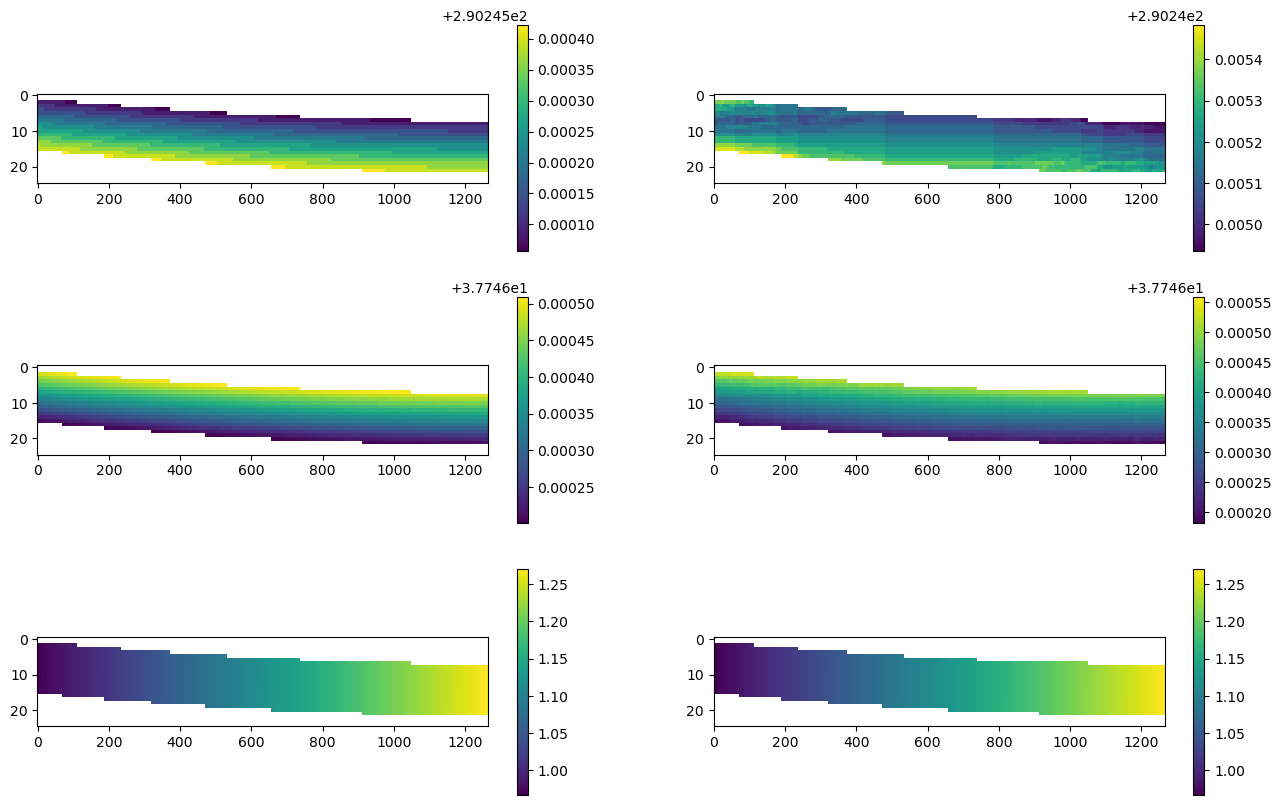

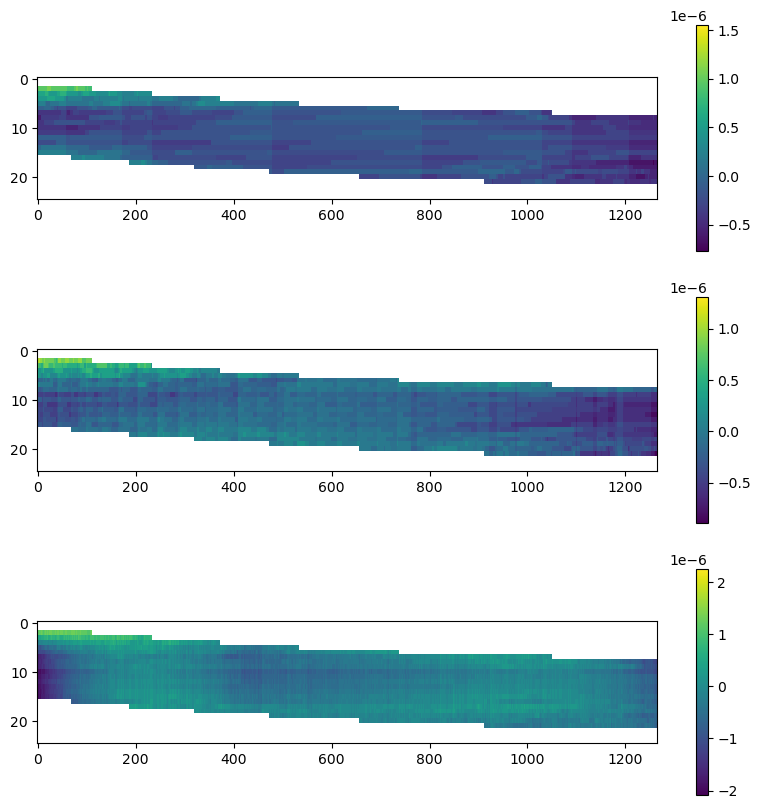

In [ ]:
jres = jnp.linalg.lstsq(vanderf, worldf.T, rcond=None)

coeffs = np.array(jres[0])
vals = (vander @ coeffs).T.reshape(3, *ss.slitshape)

worldg = ss.world_grid()

fig, axs = plt.subplots(3, 2, figsize=(16, 10))
for i, (ax1, ax2) in enumerate(axs):
    sc = ax1.imshow(worldg[i], aspect=10, interpolation='nearest')
    plt.colorbar(sc, ax=ax1)
    sc = ax2.imshow(vals[i] + (worldg[i] - worldg[i]), aspect=10, interpolation='nearest')
    plt.colorbar(sc, ax=ax2)

fig, axs = plt.subplots(3, 1, figsize=(10, 10))
for i, ax in enumerate(axs):
    sc = ax.imshow(vals[i]/worldg[i] - 1, aspect=10, interpolation='nearest')
    plt.colorbar(sc, ax=ax)

jres

How odd... precision? What if we try orthogonal polynomials?

In [ ]:
xygrf = ss.xy_grid_rescaled().reshape(2, -1)

vander = np.polynomial.legendre.legvander2d(xygrf[0], xygrf[1], [3,3])

worldf = ss.world_grid().reshape(3, -1)
msk = np.isfinite(worldf).all(axis=0)
worldf = worldf[:, msk]
vanderf = vander[msk]

res = np.linalg.lstsq(vanderf, worldf.T, rcond=None)
res

(array([[ 2.90245239e+02,  3.77463493e+01,  1.11906898e+00],
        [-2.97596329e-04,  2.68284668e-04, -2.23325216e-04],
        [ 1.10190433e-06,  4.29212790e-08, -4.95992310e-07],
        [ 3.14491626e-06,  7.14414057e-08,  1.07507340e-07],
        [-7.23013000e-05,  6.76524724e-05,  1.51923195e-01],
        [ 9.79655579e-06,  3.70719079e-07, -5.40626024e-06],
        [ 8.57320538e-06,  1.92116076e-07,  4.60079178e-07],
        [ 8.85099234e-06,  1.40651039e-07, -5.62625416e-07],
        [ 2.47514436e-05, -1.95002485e-05, -2.38406123e-04],
        [ 1.92989519e-05,  2.94765783e-07,  3.74287367e-07],
        [ 6.49152798e-06,  1.44881085e-07, -1.95396979e-06],
        [ 1.53197761e-05,  2.73450240e-07, -2.39898043e-07],
        [ 2.23831989e-06,  1.89645746e-07, -1.11188965e-05],
        [ 7.04276590e-06,  1.28119908e-07, -2.88094861e-06],
        [ 4.72681813e-06,  1.01552239e-07,  3.53086556e-08],
        [ 5.15083184e-06,  5.62174058e-08, -1.70586907e-06]], dtype=float32),
 array(

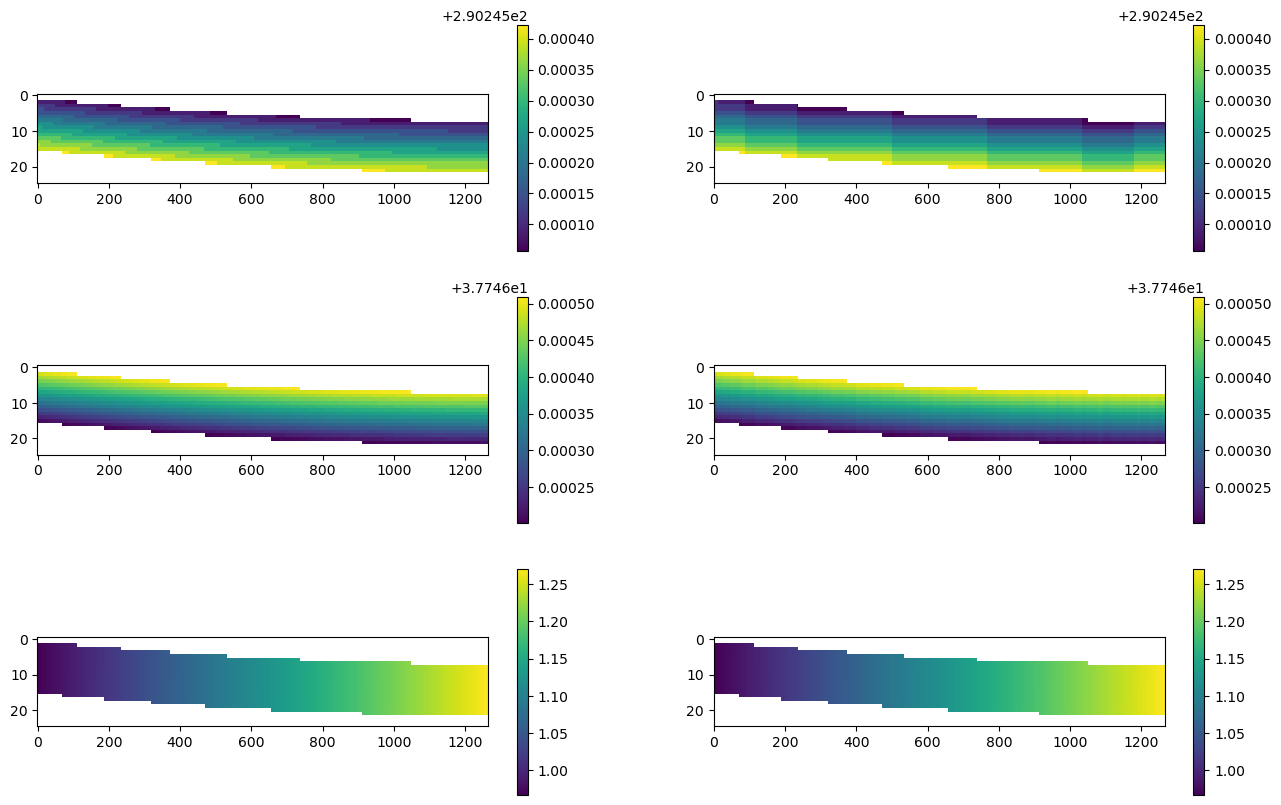

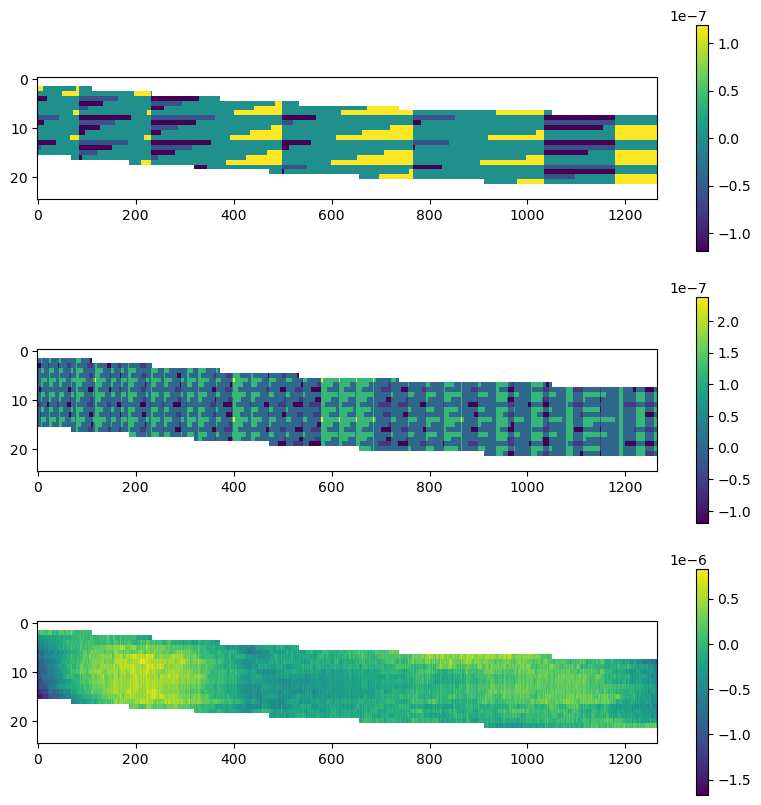

In [ ]:
coeffs = res[0]
vals = (vander @ coeffs).T.reshape(3, *ss.slitshape)

worldg = ss.world_grid()

fig, axs = plt.subplots(3, 2, figsize=(16, 10))
for i, (ax1, ax2) in enumerate(axs):
    sc = ax1.imshow(worldg[i], aspect=10, interpolation='nearest')
    plt.colorbar(sc, ax=ax1)
    sc = ax2.imshow(vals[i] + (worldg[i] - worldg[i]), aspect=10, interpolation='nearest')
    plt.colorbar(sc, ax=ax2)

fig, axs = plt.subplots(3, 1, figsize=(10, 10))
for i, ax in enumerate(axs):
    sc = ax.imshow(vals[i]/worldg[i] - 1, aspect=10, interpolation='nearest')
    plt.colorbar(sc, ax=ax)

(Array([[ 2.90245300e+02,  3.77463570e+01,  1.11906934e+00],
        [-3.12775373e-04,  2.82432884e-04, -2.22893432e-04],
        [-4.81605530e-05, -1.78813934e-07, -4.30271029e-07],
        [-8.36551189e-05,  1.17830932e-05,  2.57045031e-07],
        [-1.31130219e-04,  6.83963299e-05,  1.51923239e-01],
        [-1.33514404e-04,  6.67572021e-06, -4.60445881e-06],
        [-1.39474869e-04,  3.60608101e-06,  6.64964318e-07],
        [-1.49726868e-04,  1.14440918e-05,  1.11758709e-07],
        [ 1.19209290e-05, -2.36034393e-05, -2.38100067e-04],
        [-9.96589661e-05,  7.03334808e-06,  5.78584149e-07],
        [-1.43051147e-05, -1.16825104e-05, -1.28149986e-06],
        [-1.55001879e-04,  4.79817390e-06, -1.09663233e-07],
        [-6.49690628e-06,  4.50760126e-06, -1.11062545e-05],
        [ 4.05311584e-05, -2.96235085e-05, -2.68220901e-06],
        [-5.32120466e-05,  1.75423920e-05,  2.12923624e-07],
        [ 9.34600830e-05, -3.26633453e-05, -1.56275928e-06]],      dtype=float32),
 A

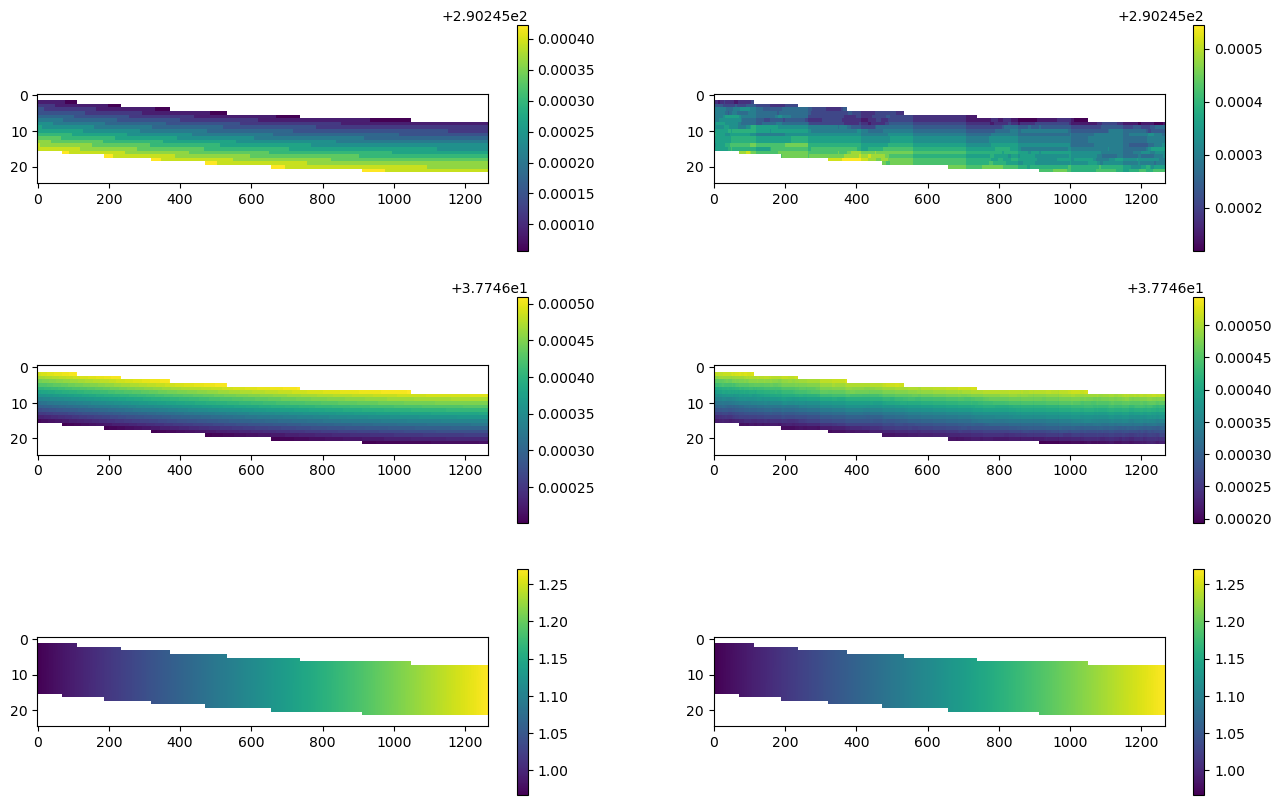

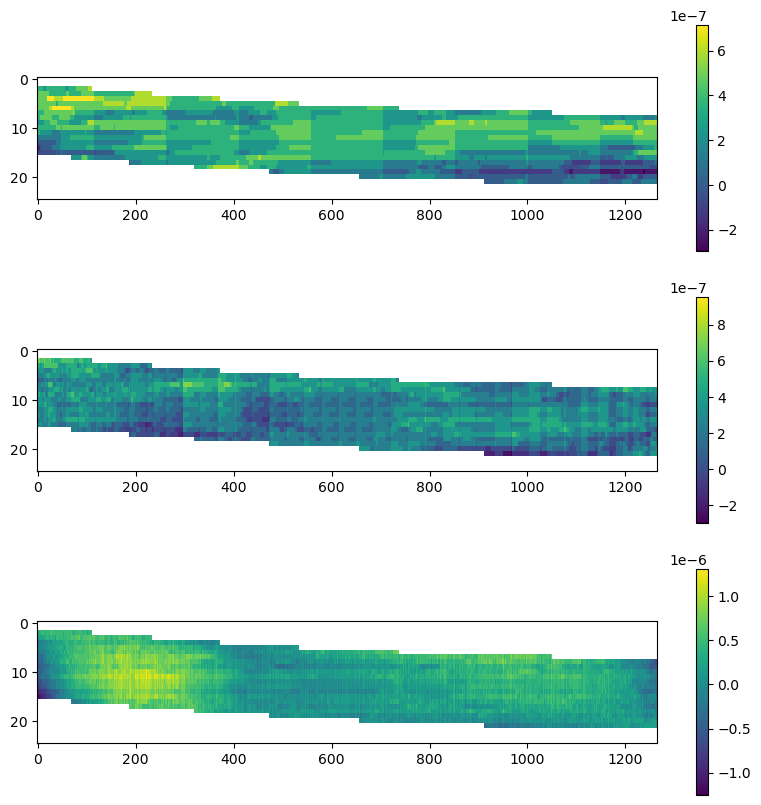

In [ ]:
jres = jnp.linalg.lstsq(vanderf, worldf.T, rcond=None)

coeffs = np.array(jres[0])
vals = (vander @ coeffs).T.reshape(3, *ss.slitshape)

worldg = ss.world_grid()

fig, axs = plt.subplots(3, 2, figsize=(16, 10))
for i, (ax1, ax2) in enumerate(axs):
    sc = ax1.imshow(worldg[i], aspect=10, interpolation='nearest')
    plt.colorbar(sc, ax=ax1)
    sc = ax2.imshow(vals[i] + (worldg[i] - worldg[i]), aspect=10, interpolation='nearest')
    plt.colorbar(sc, ax=ax2)

fig, axs = plt.subplots(3, 1, figsize=(10, 10))
for i, ax in enumerate(axs):
    sc = ax.imshow(vals[i]/worldg[i] - 1, aspect=10, interpolation='nearest')
    plt.colorbar(sc, ax=ax)

jres